In [ ]:
# ST494/ST694 Final Project
# Disease classification using symptom data
#focus: preprocessing, EDA, classification, clustering(k-means & heirarchcical)
#loading R interpreter
%load_ext rpy2.ipython

In [ ]:
%%R

# Installing required packages only if they are not already installed
required_packages <- c("readr","dplyr","tidyr","janitor","ggplot2","corrplot","e1071","rpart","caret","rpart.plot","randomForest")
installed <- rownames(installed.packages())

for (pkg in required_packages) {
  if (!(pkg %in% installed)) {
    install.packages(pkg, dependencies = TRUE)}}

# loading all required libraries
library(readr)
library(dplyr)
library(tidyr)
library(janitor)
library(ggplot2)
library(corrplot)
library(e1071)
library(rpart)
library(caret)
library(rpart.plot)
library(randomForest)

In [ ]:
%%R
library(readr)
library(dplyr)
library(tidyr)
library(ggplot2)
library(rpart)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



In [ ]:
%%R

#Load Datasets
library(readr)
# Main symptom-disease dataset
df = read_csv("final.dataset.csv")

# Symptom severity weights
severity = read_csv("Symptom-severity.csv")

# Disease descriptions (used for interpretation)
description = read_csv("symptom_Description.csv")

# Disease precautions (used for recommendation system)
precaution = read_csv("symptom_precaution.csv")

Rows: 4920 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (18): Disease, Symptom_1, Symptom_2, Symptom_3, Symptom_4, Symptom_5, Sy...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 133 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Symptom
dbl (1): weight

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 41 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Disease, Description

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 41 Columns: 5
── Column specificat

In [ ]:
%%R
#Overview of our disease symptom dataset
# Keep the first 410 observations as each disease has exactly 10 cases
df = df[1:410, ]
print(dim(df))
head(df)


[1] 410  18
# A tibble: 6 × 18
  Disease  Symptom_1 Symptom_2 Symptom_3 Symptom_4 Symptom_5 Symptom_6 Symptom_7
  <chr>    <chr>     <chr>     <chr>     <chr>     <chr>     <chr>     <chr>    
1 Fungal … itching   skin_rash nodal_sk… dischrom… <NA>      <NA>      <NA>     
2 Fungal … skin_rash nodal_sk… dischrom… <NA>      <NA>      <NA>      <NA>     
3 Fungal … itching   nodal_sk… dischrom… <NA>      <NA>      <NA>      <NA>     
4 Fungal … itching   skin_rash dischrom… <NA>      <NA>      <NA>      <NA>     
5 Fungal … itching   skin_rash nodal_sk… <NA>      <NA>      <NA>      <NA>     
6 Fungal … skin_rash nodal_sk… dischrom… <NA>      <NA>      <NA>      <NA>     
# ℹ 10 more variables: Symptom_8 <chr>, Symptom_9 <chr>, Symptom_10 <chr>,
#   Symptom_11 <chr>, Symptom_12 <chr>, Symptom_13 <chr>, Symptom_14 <chr>,
#   Symptom_15 <chr>, Symptom_16 <chr>, Symptom_17 <chr>


In [ ]:
%%R

#So we have 41 diseases in our data set and up to 17 symptoms for each
print("number of symptom columns")
print(length(df[,-1]))
print("number of disease-symptom entries")
print(nrow(df))
print("number of unique diseases")
print(length(unique(df$Disease)))



[1] "number of symptom columns"
[1] 17
[1] "number of disease-symptom entries"
[1] 410
[1] "number of unique diseases"
[1] 41


In [ ]:
%%R

# Check the number of entries for each unique disease
disease_counts = df |>
  group_by(Disease) |>
  summarise(count = n())

print(disease_counts, n =41)
#we see each of the 41 diseases has 10 entries so our data is balanced

# A tibble: 41 × 2
   Disease                                 count
   <chr>                                   <int>
 1 (vertigo) Paroymsal  Positional Vertigo    10
 2 AIDS                                       10
 3 Acne                                       10
 4 Alcoholic hepatitis                        10
 5 Allergy                                    10
 6 Arthritis                                  10
 7 Bronchial Asthma                           10
 8 Cervical spondylosis                       10
 9 Chicken pox                                10
10 Chronic cholestasis                        10
11 Common Cold                                10
12 Dengue                                     10
13 Diabetes                                   10
14 Dimorphic hemmorhoids(piles)               10
15 Drug Reaction                              10
16 Fungal infection                           10
17 GERD                                       10
18 Gastroenteritis                            10
1

In [ ]:
%%R
#check for missing data
print(colSums(is.na(df)))
#too many missing values to remove rows, so we will fill in na values
df[is.na(df)] = ""


   Disease  Symptom_1  Symptom_2  Symptom_3  Symptom_4  Symptom_5  Symptom_6 
         0          0          0          0         58        121        191 
 Symptom_7  Symptom_8  Symptom_9 Symptom_10 Symptom_11 Symptom_12 Symptom_13 
       232        256        278        288        331        356        376 
Symptom_14 Symptom_15 Symptom_16 Symptom_17 
       389        390        398        408 


In [ ]:
%%R
#create column with all symptoms for each disease entry
#want to collapse by " " but some entries have weird space like dischromic _patches below for example
df$Symptoms = apply(df[,2:18], 1, paste, collapse = ",")
print(head(df$Symptoms))
length(unique(df$Symptoms))
#304 unique symptoms


[1] "itching,skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,"
[2] "skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,,"       
[3] "itching,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,,"         
[4] "itching,skin_rash,dischromic _patches,,,,,,,,,,,,,,"                    
[5] "itching,skin_rash,nodal_skin_eruptions,,,,,,,,,,,,,,"                   
[6] "skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,,,"       
[1] 304


In [ ]:
%%R
#create data for modelling
model_df = df[, c("Disease","Symptoms")]
model_df$Disease = as.factor(model_df$Disease)
head(model_df)

# A tibble: 6 × 2
  Disease          Symptoms                                                     
  <fct>            <chr>                                                        
1 Fungal infection itching,skin_rash,nodal_skin_eruptions,dischromic _patches,,…
2 Fungal infection skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,…
3 Fungal infection itching,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,,,…
4 Fungal infection itching,skin_rash,dischromic _patches,,,,,,,,,,,,,,          
5 Fungal infection itching,skin_rash,nodal_skin_eruptions,,,,,,,,,,,,,,         
6 Fungal infection skin_rash,nodal_skin_eruptions,dischromic _patches,,,,,,,,,,…


In [ ]:
%%R
# Creating a model_df with all 410 original entries
if (!require("janitor")){install.packages("janitor")}

# Getting all unique symptoms from the entire dataset
all_symptoms = unique(unlist(strsplit(df$Symptoms, ",")))
all_symptoms = all_symptoms[all_symptoms != ""]

#clean names to get rid of weird spaces in some symptoms
cleaned_symptom_names = janitor::make_clean_names(all_symptoms)

# Create an empty dataframe
one_hot_symptom_df = data.frame(matrix(0, nrow = nrow(df), ncol = length(cleaned_symptom_names)))
colnames(one_hot_symptom_df) = cleaned_symptom_names

# fill data frame for each entry
for (i in 1:nrow(df)) {
  row_symptoms = unlist(strsplit(df$Symptoms[i], ","))
  row_symptoms = row_symptoms[row_symptoms != ""]
  cleaned_row_symptoms = janitor::make_clean_names(row_symptoms)
  for (symptom_cleaned in cleaned_row_symptoms) {
    if (symptom_cleaned %in% colnames(one_hot_symptom_df)) {
      one_hot_symptom_df[i, symptom_cleaned] = 1
    }
  }
}

# Combine the Disease column from the original df
model_df = bind_cols(Disease = as.factor(df$Disease), one_hot_symptom_df)

print(dim(model_df))
head(model_df[1:5, 1:10])


[1] 410 132
           Disease itching skin_rash nodal_skin_eruptions dischromic_patches
1 Fungal infection       1         1                    1                  1
2 Fungal infection       0         1                    1                  1
3 Fungal infection       1         0                    1                  1
4 Fungal infection       1         1                    0                  1
5 Fungal infection       1         1                    1                  0
  continuous_sneezing shivering chills watering_from_eyes stomach_pain
1                   0         0      0                  0            0
2                   0         0      0                  0            0
3                   0         0      0                  0            0
4                   0         0      0                  0            0
5                   0         0      0                  0            0


Loading required package: janitor
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘snakecase’

trying URL 'https://cran.rstudio.com/src/contrib/snakecase_0.11.1.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/janitor_2.2.1.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp7hT2Od/downloaded_packages’
In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘janitor’


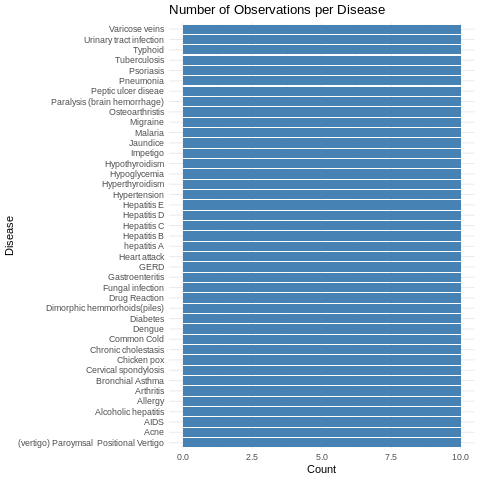

In [ ]:
%%R
#2 Exploratory Data analysis

# counting number of observations per disease
disease_counts <- model_df %>%
  group_by(Disease) %>%
  summarise(count = n())

ggplot(disease_counts, aes(x = reorder(Disease, count), y = count)) +
  geom_bar(stat = "identity", fill = "steelblue") +coord_flip() +labs(title = "Number of Observations per Disease",x = "Disease",y = "Count") +theme_minimal()

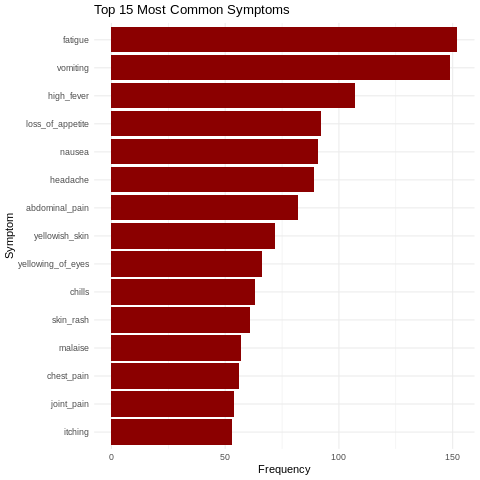

In [ ]:
%%R

# removing Disease column
symptom_matrix <- model_df %>% select(-Disease)

# counting how often each symptom appears
symptom_counts <- colSums(symptom_matrix)
symptom_df <- data.frame(Symptom = names(symptom_counts),Count = symptom_counts)

# plotting top 15 most common symptoms
top_symptoms <- symptom_df %>%
  arrange(desc(Count)) %>%
  slice(1:15)
ggplot(top_symptoms, aes(x = reorder(Symptom, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "darkred") +
  coord_flip() +
  labs(title = "Top 15 Most Common Symptoms",x = "Symptom",y = "Frequency") +theme_minimal()

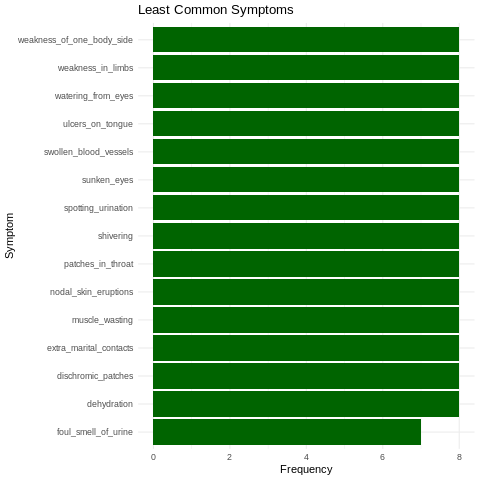

In [ ]:
%%R
# plotting bottom 15 least common symptoms
rare_symptoms <- symptom_df %>%
  arrange(Count) %>%
  slice(1:15)

ggplot(rare_symptoms, aes(x = reorder(Symptom, Count), y = Count)) +
  geom_bar(stat = "identity", fill = "darkgreen") +
  coord_flip() +
  labs(title = "Least Common Symptoms",x = "Symptom",y = "Frequency") +theme_minimal()

Loading required package: corrplot
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/corrplot_0.95.tar.gz'
Content type 'application/x-gzip' length 3745190 bytes (3.6 MB)
downloaded 3.6 MB


The downloaded source packages are in
	‘/tmp/Rtmp7hT2Od/downloaded_packages’
corrplot 0.95 loaded
In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘corrplot’


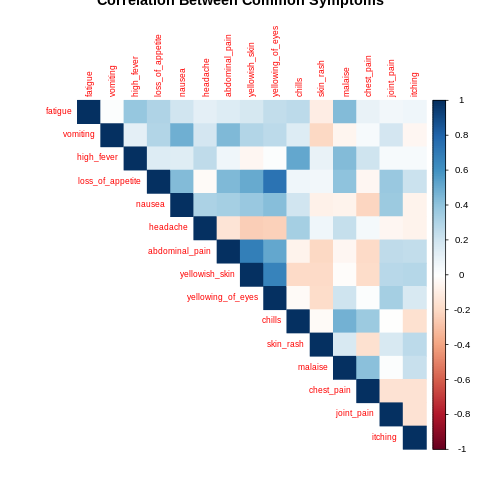

In [ ]:
%%R
# using only top symptoms to avoid messy plot
if(!require("corrplot")){install.packages("corrplot")}
library(corrplot)
top_symptom_names <- top_symptoms$Symptom
top_matrix <- symptom_matrix[, top_symptom_names]

# plotting correlation matrix
cor_matrix <- cor(top_matrix)
corrplot(cor_matrix, method = "color", type = "upper",tl.cex = 0.7, title = "Correlation Between Common Symptoms")

In [ ]:
%%R
#3 Supervised Learning: Classification through modelling

#Create test and training sets for our data, using a 80/20 split while ensuring
#balance in each type of disease as 8/10 observations will be in the training data
#and 2/10 will be in test for each disease type
set.seed(111)
train = data.frame()
test = data.frame()

unique_diseases = levels(model_df$Disease)

for (disease in unique_diseases) {
    disease_subset = model_df[model_df$Disease == disease, ]

    train_ind = sample(1:nrow(disease_subset), 8)
    test_ind = setdiff(1:nrow(disease_subset), train_ind)

    train = rbind(train, disease_subset[train_ind, ])
    test = rbind(test, disease_subset[test_ind, ])
}
head(test[,1:6])

                                    Disease itching skin_rash
368 (vertigo) Paroymsal  Positional Vertigo       0         0
370 (vertigo) Paroymsal  Positional Vertigo       0         0
375                                    Acne       0         1
378                                    Acne       0         1
62                                     AIDS       0         0
64                                     AIDS       0         0
    nodal_skin_eruptions dischromic_patches continuous_sneezing
368                    0                  0                   0
370                    0                  0                   0
375                    0                  0                   0
378                    0                  0                   0
62                     0                  0                   0
64                     0                  0                   0


In [ ]:

%%R
if(!require("e1071")){install.packages("e1071")}
library(e1071)
#Naive Bayes model
model_nb = naiveBayes(Disease ~ ., data = train)
pred = predict(model_nb, test)
pred_prob = predict(model_nb, test, type = "raw")
print(head(pred_prob))
mean(pred == test$Disease)


     (vertigo) Paroymsal  Positional Vertigo         Acne         AIDS
[1,]                            1.000000e+00 4.012343e-25 3.341517e-26
[2,]                            1.000000e+00 2.020094e-29 1.682353e-30
[3,]                            9.171922e-31 1.000000e+00 1.012445e-21
[4,]                            9.171922e-31 1.000000e+00 1.012445e-21
[5,]                            3.468125e-33 4.596851e-23 1.000000e+00
[6,]                            6.888448e-29 9.130342e-19 1.000000e+00
     Alcoholic hepatitis      Allergy    Arthritis Bronchial Asthma
[1,]        3.208811e-32 1.763485e-24 4.335968e-33     1.330473e-34
[2,]        1.615539e-36 8.878615e-29 2.183029e-37     6.698531e-39
[3,]        1.213329e-34 5.343179e-20 1.313754e-28     4.031198e-30
[4,]        1.213329e-34 5.343179e-20 1.313754e-28     4.031198e-30
[5,]        4.587889e-37 2.020385e-22 4.967620e-31     1.221411e-25
[6,]        9.112541e-33 4.012923e-18 9.866770e-27     3.027576e-28
     Cervical spondylosis  

Loading required package: e1071
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependency ‘proxy’

trying URL 'https://cran.rstudio.com/src/contrib/proxy_0.4-29.tar.gz'
trying URL 'https://cran.rstudio.com/src/contrib/e1071_1.7-17.tar.gz'

The downloaded source packages are in
	‘/tmp/Rtmp7hT2Od/downloaded_packages’

Attaching package: ‘e1071’

The following object is masked from ‘package:ggplot2’:

    element

In addition: Warning message:
In library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE,  :
  there is no package called ‘e1071’


In [ ]:
%%R
#Naive Bayes: baseline generative classifier
library(e1071)

nb_model <- naiveBayes(Disease ~ ., data = train)
nb_pred  <- predict(nb_model, test)

nb_acc <- mean(nb_pred == test$Disease)
nb_acc


[1] 1


In [ ]:
%%R
install.packages("glmnet", repos = "https://cloud.r-project.org", dependencies = TRUE)
library(glmnet)

In [ ]:
%%R
#Multivariate logitsic regression model and lasso model
if(!require("glmnet")){install.packages("glmnet")}
library(glmnet)


x_train = train[,-1]
y_train = train[,1]
x_test = test[,-1]
y_test = test[,1]
model_lasso = cv.glmnet(x_train, y_train, alpha = 1, family = "multinomial", type.measure = "class")

best_lambda = model_lasso$lambda.min
print(best_lambda)

pred = predict(model_lasso, s = best_lambda, newx = x_test, type = "class")
mean(pred == y_test)

plot(model_lasso)

coef(model_lasso, s = best_lambda)



In [ ]:
%%R
#single tree model
model_tree = rpart(Disease ~ ., data = train)
print(model_tree)
mean(predict(model_tree, test, type = "class") == test$Disease)

n= 328 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

        1) root 328 320 (vertigo) Paroymsal  Positional Vertigo (0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024)  
          2) restlessness>=0.5 16   8 Diabetes (0 0 0 0 0 0 0 0 0 0 0 0 0.5 0 0 0 0 0 0 0 0 0 0 0 0 0.5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0) *
          3) restlessness< 0.5 312 304 (vertigo) Paroymsal  Positional Vertigo (0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026)  
            6) mild_fever< 0.5 288 280 (vertigo) Paroymsal  Positional Vertigo (0.028 0.028 0.028 0.028 0.028 0.028 0.028 0.028 0 0.028 0.028 0.028 0 0

In [ ]:
%%R
#Smaller tree model

model_tree_2 = rpart(Disease ~ ., data = train, method = "class", control = rpart.control(maxdepth = 15))
print(model_tree_2)
mean(predict(model_tree_2, test, type = "class") == test$Disease)


n= 328 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

    1) root 328 320 (vertigo) Paroymsal  Positional Vertigo (0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024 0.024)  
      2) restlessness>=0.5 16   8 Diabetes (0 0 0 0 0 0 0 0 0 0 0 0 0.5 0 0 0 0 0 0 0 0 0 0 0 0 0.5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0) *
      3) restlessness< 0.5 312 304 (vertigo) Paroymsal  Positional Vertigo (0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026 0.026)  
        6) mild_fever< 0.5 288 280 (vertigo) Paroymsal  Positional Vertigo (0.028 0.028 0.028 0.028 0.028 0.028 0.028 0.028 0 0.028 0.028 0.028 0 0.028 0.028 0.028

In [ ]:
%%R
#Prune Tree

model_tree_3 = rpart(Disease ~ ., data = train, method = "class")
printcp(model_tree_3)
model_tree_3 = prune(model_tree_3, cp =0.01)
#rpart.plot(model_tree_3)
print(mean(predict(model_tree_3, test, type = "class") == test$Disease))


Classification tree:
rpart(formula = Disease ~ ., data = train, method = "class")

Variables actually used in tree construction:
 [1] altered_sensorium           bladder_discomfort         
 [3] chest_pain                  coma                       
 [5] continuous_sneezing         dehydration                
 [7] dischromic_patches          family_history             
 [9] fast_heart_rate             fatigue                    
[11] high_fever                  irritability               
[13] knee_pain                   loss_of_balance            
[15] mild_fever                  muscle_pain                
[17] nausea                      obesity                    
[19] pain_in_anal_region         passage_of_gases           
[21] receiving_blood_transfusion red_sore_around_nose       
[23] red_spots_over_body         restlessness               
[25] silver_like_dusting         spotting_urination         
[27] stiff_neck                  stomach_pain               
[29] swelling_of

                                    368                                     370 
(vertigo) Paroymsal  Positional Vertigo (vertigo) Paroymsal  Positional Vertigo 
                                    375                                     378 
                                   Acne                                    Acne 
                                     62                                      64 
                                   AIDS                                    AIDS 
41 Levels: (vertigo) Paroymsal  Positional Vertigo Acne ... Varicose veins
[1] 1


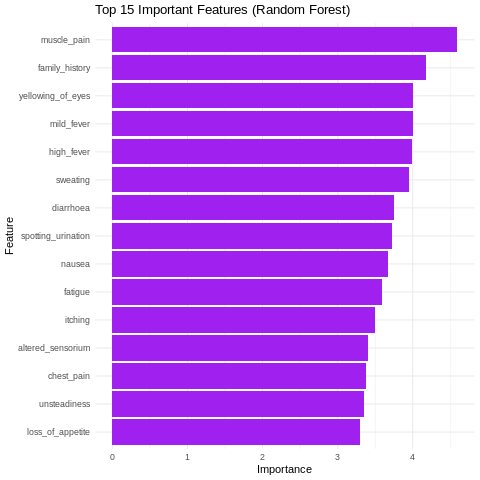

In [ ]:
%%R
#Random Forest model
if(!require("randomForest")){install.packages("randomForest")}
library(randomForest)

rf_model = randomForest(Disease ~ ., data = train)
pred = predict(rf_model, test)
print(head(pred))
print(mean(pred == test$Disease))
#100% accuracy!

# Variable importance from Random Forest
importance_df <- data.frame(
  Feature = rownames(importance(rf_model)),
  Importance = importance(rf_model)[,1]
)

# Top 15 important features
top_features <- importance_df %>%
  arrange(desc(Importance)) %>%
  slice(1:15)

ggplot(top_features, aes(x = reorder(Feature, Importance), y = Importance)) +
  geom_bar(stat = "identity", fill = "purple") +
  coord_flip() +
  labs(title = "Top 15 Important Features (Random Forest)",
       x = "Feature",
       y = "Importance") +
  theme_minimal()

In [ ]:
# Confusion matrix for Random Forest
#too big: table(Predicted = pred, Actual = test$Disease)

                                         Actual
Predicted                                 (vertigo) Paroymsal  Positional Vertigo
  (vertigo) Paroymsal  Positional Vertigo                                       2
  Acne                                                                          0
  AIDS                                                                          0
  Alcoholic hepatitis                                                           0
  Allergy                                                                       0
  Arthritis                                                                     0
  Bronchial Asthma                                                              0
  Cervical spondylosis                                                          0
  Chicken pox                                                                   0
  Chronic cholestasis                                                           0
  Common Cold                                     

In [ ]:
%%R
#Pca and random forests using principal components

model_symptoms = train[,-1]
pca = prcomp(model_symptoms)
summary(pca)

Importance of components:
                          PC1    PC2     PC3     PC4    PC5     PC6     PC7
Standard deviation     0.8630 0.7930 0.63818 0.62617 0.5613 0.48855 0.46794
Proportion of Variance 0.1201 0.1014 0.06567 0.06322 0.0508 0.03848 0.03531
Cumulative Proportion  0.1201 0.2215 0.28715 0.35037 0.4012 0.43965 0.47496
                           PC8     PC9    PC10    PC11    PC12    PC13    PC14
Standard deviation     0.46409 0.44578 0.41722 0.39607 0.38432 0.37960 0.35636
Proportion of Variance 0.03473 0.03204 0.02807 0.02529 0.02382 0.02323 0.02048
Cumulative Proportion  0.50969 0.54173 0.56979 0.59509 0.61890 0.64214 0.66261
                          PC15    PC16    PC17    PC18    PC19    PC20    PC21
Standard deviation     0.35053 0.33106 0.32611 0.31927 0.31427 0.31036 0.29620
Proportion of Variance 0.01981 0.01767 0.01715 0.01644 0.01592 0.01553 0.01415
Cumulative Proportion  0.68243 0.70010 0.71725 0.73368 0.74960 0.76514 0.77928
                          PC22    PC23

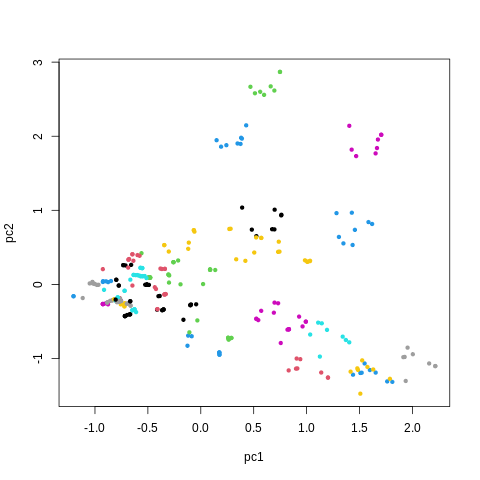

In [ ]:
%%R
plot(pca$x[,1], pca$x[,2], col = train$Disease, pch = 20, xlab = "pc1", ylab = "pc2")


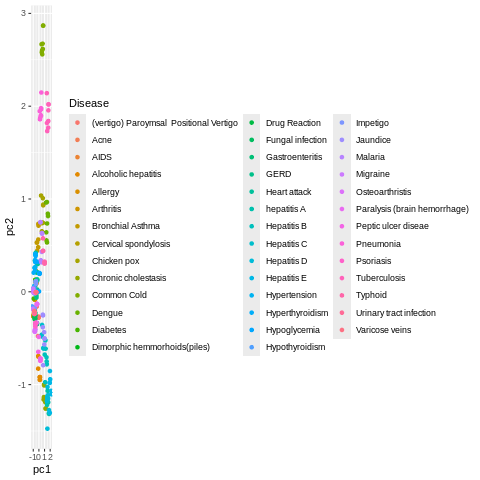

In [ ]:
%%R
pca_df = data.frame(pc1 = pca$x[,1], pc2 = pca$x[,2], Disease = train$Disease)
ggplot(pca_df, aes(x = pc1, y = pc2, color = Disease)) + geom_point()

     PC         PVE CumulativePVE
1   PC1 0.120078640     0.1200786
2   PC2 0.101397833     0.2214765
3   PC3 0.065668604     0.2871451
4   PC4 0.063220321     0.3503654
5   PC5 0.050802804     0.4011682
6   PC6 0.038484065     0.4396523
7   PC7 0.035306467     0.4749587
8   PC8 0.034727052     0.5096858
9   PC9 0.032041283     0.5417271
10 PC10 0.028067921     0.5697950
11 PC11 0.025294401     0.5950894
12 PC12 0.023815053     0.6189044
13 PC13 0.023234146     0.6421386
14 PC14 0.020475963     0.6626146
15 PC15 0.019812091     0.6824266
16 PC16 0.017671484     0.7000981
17 PC17 0.017146889     0.7172450
18 PC18 0.016435465     0.7336805
19 PC19 0.015924473     0.7496050
20 PC20 0.015530707     0.7651357
21 PC21 0.014146332     0.7792820
22 PC22 0.013516133     0.7927981
23 PC23 0.012907902     0.8057060
24 PC24 0.012549969     0.8182560
25 PC25 0.011983366     0.8302394
26 PC26 0.011160035     0.8413994
27 PC27 0.010198292     0.8515977
28 PC28 0.009914126     0.8615118
29 PC29 0.0096

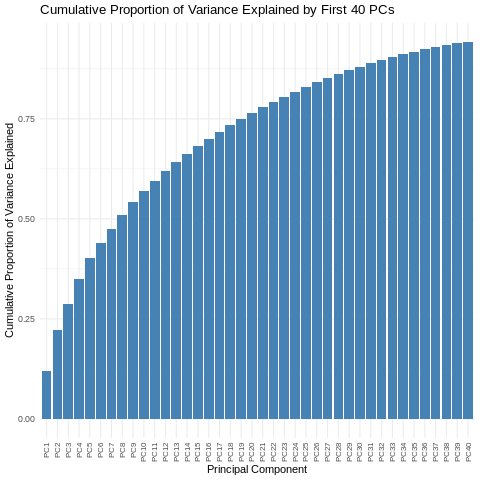

In [ ]:
%%R

# Proportion of variance explained
pve <- (pca$sdev^2) / sum(pca$sdev^2)

# Show first 40 PCs
pve_df <- data.frame(
  PC = paste0("PC", 1:40),
  PVE = pve[1:40],
  CumulativePVE = cumsum(pve[1:40])
)

# Convert PC to a factor with ordered levels
pve_df$PC <- factor(pve_df$PC, levels = paste0("PC", 1:40))

print(pve_df)

# Scree plot for Cumulative Proportion of Variance Explained
ggplot(pve_df, aes(x = PC, y = CumulativePVE)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "Cumulative Proportion of Variance Explained by First 40 PCs",
       x = "Principal Component",
       y = "Cumulative Proportion of Variance Explained") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 8))

In [ ]:
%%R
#from above graph we see the increase in cummulative sum proportion of variance explained starts to decrease around principal
#component 10-15, thus we will use first 15 components
#pca for classification (use first 15 components)
set.seed(111)
model_pca = data.frame(Disease = train$Disease, pca$x[,1:15])
model_pca$Disease = as.factor(model_pca$Disease)
print(head(model_pca))

# Transform the test data using the same PCA object
# First, select only the symptom columns from the test set
test_x = test[,-1]
# Apply the PCA transformation
test_pca_x = predict(pca, newdata = test_x)
# Create a new test dataframe with Disease and the transformed principal components
test_pca = data.frame(Disease = test$Disease, test_pca_x[,1:15])
test_pca$Disease = as.factor(test_pca$Disease)

model_rf_2 = randomForest(Disease ~ ., data = model_pca)
pred_2 = predict(model_rf_2, test_pca)
mean(pred_2 == test_pca$Disease)

                                    Disease         PC1        PC2        PC3
364 (vertigo) Paroymsal  Positional Vertigo -0.16406680 -0.4772854 -0.4231806
363 (vertigo) Paroymsal  Positional Vertigo -0.40019819 -0.1590845 -0.3647855
367 (vertigo) Paroymsal  Positional Vertigo -0.04376113 -0.2684581 -0.3913563
361 (vertigo) Paroymsal  Positional Vertigo -0.09802796 -0.2798160 -0.4545268
369 (vertigo) Paroymsal  Positional Vertigo -0.09802796 -0.2798160 -0.4545268
365 (vertigo) Paroymsal  Positional Vertigo -0.38738898 -0.1563835 -0.4883855
          PC4         PC5         PC6         PC7       PC8         PC9
364 0.7860384 -0.17659431 -0.11950245  0.02426711 0.2646013 -0.15589699
363 0.7833383  0.41327141 -0.20793304 -0.26286137 0.1536153  0.02493061
367 1.1262042  0.15220187 -0.09357013 -0.17212896 0.3097316 -0.22008139
361 1.1850132  0.16782609 -0.19710189 -0.19590992 0.3842104 -0.22597247
369 1.1850132  0.16782609 -0.19710189 -0.19590992 0.3842104 -0.22597247
365 0.8255736  0.04508

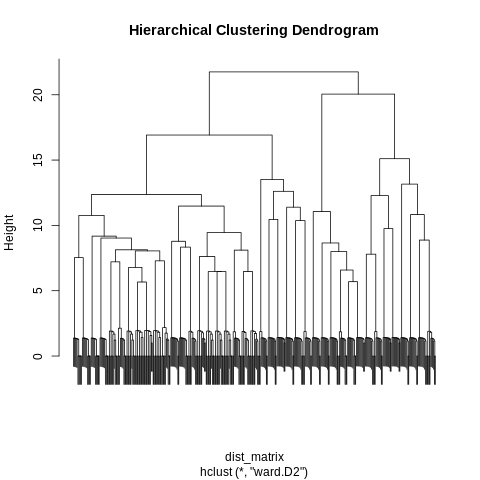

In [ ]:
%%R
#4 clustering

#hierarchial clustering

# distance matrix
dist_matrix <- dist(symptom_matrix)

# hierarchical clustering
hc <- hclust(dist_matrix, method = "ward.D2")

# plot dendrogram
plot(hc, labels = FALSE, main = "Hierarchical Clustering Dendrogram")

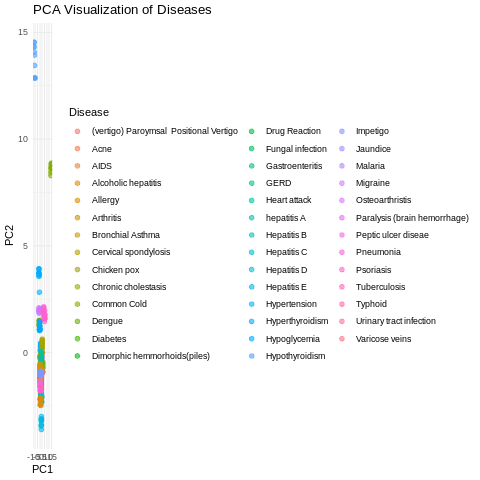

In [ ]:
%%R
pca <- prcomp(symptom_matrix, scale. = TRUE)

pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  Disease = model_df$Disease
)

ggplot(pca_df, aes(x = PC1, y = PC2, color = Disease)) +
  geom_point(size = 2, alpha = 0.6) +
  labs(title = "PCA Visualization of Diseases") +
  theme_minimal()

In [ ]:
%%R
#kmeans clustering

#try with k =10
set.seed(113)
train_x = train[,-1]
train_y = train[,1]
test_x = test[,-1]
test_y = test[,1]
model_kmean3 = kmeans(train_x, centers = 10)
head(model_kmean3)
cluster_df = train_x
cluster_df$cluster = model_kmean3$cluster
cluster_df$Disease = train_y

#reorganize
other_cols = setdiff(names(cluster_df), c('Disease', 'cluster'))
new_col_order = c('Disease', 'cluster', as.character(other_cols))
cluster_df = cluster_df[, new_col_order]
print(table(cluster_df$Disease, cluster_df$cluster))
head(cluster_df[,1:10])
#grouped by symptoms, analyze what symptoms in each group check similar diseases
#similar symptoms
#harder diagonosis if similar disease have similar symptom


                                         
                                          1 2 3 4 5 6 7 8 9 10
  (vertigo) Paroymsal  Positional Vertigo 0 0 0 0 0 0 0 8 0  0
  Acne                                    0 0 0 8 0 0 0 0 0  0
  AIDS                                    8 0 0 0 0 0 0 0 0  0
  Alcoholic hepatitis                     0 0 0 0 0 0 0 0 0  8
  Allergy                                 8 0 0 0 0 0 0 0 0  0
  Arthritis                               8 0 0 0 0 0 0 0 0  0
  Bronchial Asthma                        8 0 0 0 0 0 0 0 0  0
  Cervical spondylosis                    8 0 0 0 0 0 0 0 0  0
  Chicken pox                             0 8 0 0 0 0 0 0 0  0
  Chronic cholestasis                     0 0 0 0 0 0 0 0 0  8
  Common Cold                             0 0 0 0 8 0 0 0 0  0
  Dengue                                  0 8 0 0 0 0 0 0 0  0
  Diabetes                                0 0 0 0 0 8 0 0 0  0
  Dimorphic hemmorhoids(piles)            8 0 0 0 0 0 0 0 0  0
  Drug Reacti

In [ ]:
%%R
#assign x values in test to a cluster
test_cluster = numeric(nrow(test_x))
for (i in 1:nrow(test_x)) {
    distance = apply(model_kmean3$centers, 1, function(x) sum((test_x[i, ] - x)^2))
    test_cluster[i] = which.min(distance)
}
test_k3 = test_x
test_k3$cluster = test_cluster
test_k3$Disease = test_y

ordered_cols = names(cluster_df)
test_k3 = test_k3[, ordered_cols]
head(test_k3[, 1:10])


                                    Disease cluster itching skin_rash
368 (vertigo) Paroymsal  Positional Vertigo       8       0         0
370 (vertigo) Paroymsal  Positional Vertigo       8       0         0
375                                    Acne       4       0         1
378                                    Acne       4       0         1
62                                     AIDS       1       0         0
64                                     AIDS       1       0         0
    nodal_skin_eruptions dischromic_patches continuous_sneezing shivering
368                    0                  0                   0         0
370                    0                  0                   0         0
375                    0                  0                   0         0
378                    0                  0                   0         0
62                     0                  0                   0         0
64                     0                  0                   0   

In [ ]:
%%R
#analyze clusters
cluster_sum = cluster_df %>% group_by(cluster) %>% summarise_at(vars(-Disease), sum)
print(cluster_sum)

# A tibble: 10 × 132
   cluster itching skin_rash nodal_skin_eruptions dischromic_patches
     <int>   <dbl>     <dbl>                <dbl>              <dbl>
 1       1      14        26                    6                  7
 2       2       7        15                    0                  0
 3       3       7         0                    0                  0
 4       4       0         7                    0                  0
 5       5       0         0                    0                  0
 6       6       0         0                    0                  0
 7       7       7         0                    0                  0
 8       8       0         0                    0                  0
 9       9       0         0                    0                  0
10      10       7         0                    0                  0
# ℹ 127 more variables: continuous_sneezing <dbl>, shivering <dbl>,
#   chills <dbl>, watering_from_eyes <dbl>, stomach_pain <dbl>, acidity <dbl>,
#   

In [ ]:
%%R
#find common diseases among clusters
common_disease = data.frame()
for (i in unique(cluster_df$cluster)){
    disease_count = cluster_df %>% filter(cluster == i) %>% group_by(Disease) %>% summarise(count = n()) %>% arrange(desc(count))
    fifth_disease_n = ifelse(nrow(disease_count) >= 5, disease_count$count[5], 0)

    top_5 = disease_count %>% filter(count >= fifth_disease_n) %>% head(5) %>% mutate(cluster = i)
    cat(paste("cluster", i, "most common diseases\n"))
    print(top_5)
    common_disease = rbind(common_disease, top_5)
}

cluster 8 most common diseases
# A tibble: 1 × 3
  Disease                                 count cluster
  <fct>                                   <int>   <int>
1 (vertigo) Paroymsal  Positional Vertigo     8       8
cluster 4 most common diseases
# A tibble: 1 × 3
  Disease count cluster
  <fct>   <int>   <int>
1 Acne        8       4
cluster 1 most common diseases
# A tibble: 5 × 3
  Disease              count cluster
  <fct>                <int>   <int>
1 AIDS                     8       1
2 Allergy                  8       1
3 Arthritis                8       1
4 Bronchial Asthma         8       1
5 Cervical spondylosis     8       1
cluster 10 most common diseases
# A tibble: 5 × 3
  Disease             count cluster
  <fct>               <int>   <int>
1 Alcoholic hepatitis     8      10
2 Chronic cholestasis     8      10
3 Hepatitis C             8      10
4 Peptic ulcer diseae     8      10
5 Tuberculosis            8      10
cluster 2 most common diseases
# A tibble: 2 × 3
  D

In [ ]:
%%R
#find common symptoms in each cluster (analyze with above)
common_symptom = data.frame()
for (i in 1:nrow(cluster_sum)){
    cluster_num = cluster_sum$cluster[i]
    symptoms_cluster = cluster_sum[i, ] %>% select(-cluster) %>% pivot_longer(everything(), names_to = "Symptom", values_to = "Count") %>%
    arrange(desc(Count)) %>% head(5) %>% mutate(cluster = cluster_num)
    cat("cluster", i, "5 most common symptoms\n")
    print(symptoms_cluster)
    common_symptom = rbind(common_symptom, symptoms_cluster)
}

cluster 1 5 most common symptoms
# A tibble: 5 × 3
  Symptom    Count cluster
  <chr>      <dbl>   <int>
1 skin_rash     26       1
2 vomiting      26       1
3 dizziness     21       1
4 chest_pain    20       1
5 high_fever    20       1
cluster 2 5 most common symptoms
# A tibble: 5 × 3
  Symptom             Count cluster
  <chr>               <dbl>   <int>
1 malaise                16       2
2 red_spots_over_body    16       2
3 skin_rash              15       2
4 loss_of_appetite       15       2
5 headache               15       2
cluster 3 5 most common symptoms
# A tibble: 5 × 3
  Symptom           Count cluster
  <chr>             <dbl>   <int>
1 abdominal_pain       31       3
2 dark_urine           29       3
3 vomiting             28       3
4 yellowish_skin       28       3
5 yellowing_of_eyes    23       3
cluster 4 5 most common symptoms
# A tibble: 5 × 3
  Symptom            Count cluster
  <chr>              <dbl>   <int>
1 skin_rash              7       4
2 blackheads

In [ ]:
%%R
#Output table

disease_summary = common_disease %>% group_by(cluster) %>% summarise(Disease = paste(Disease, collapse = ", "))
symptom_summary = common_symptom %>% group_by(cluster) %>% summarise(Symptom = paste(Symptom, collapse = ", "))
table_summary = merge(disease_summary, symptom_summary, by = "cluster")
table_summary = table_summary %>% arrange(cluster)
print(table_summary)

   cluster
1        1
2        2
3        3
4        4
5        5
6        6
7        7
8        8
9        9
10      10
                                                                                    Disease
1                          AIDS, Allergy, Arthritis, Bronchial Asthma, Cervical spondylosis
2                                                                       Chicken pox, Dengue
3                                           hepatitis A, Hepatitis D, Hepatitis E, Jaundice
4                                                                                      Acne
5                                    Common Cold, Hypoglycemia, Malaria, Pneumonia, Typhoid
6                                                                                  Diabetes
7                                                                               Hepatitis B
8                                                   (vertigo) Paroymsal  Positional Vertigo
9                                                  

In [ ]:
%%R
#kmeans with k = 25
model_kmean25 = kmeans(train_x, centers = 25)
head(model_kmean25)
cluster_2_df = train_x
cluster_2_df$cluster = model_kmean25$cluster
cluster_2_df$Disease = train_y

#reorganize
other_cols = setdiff(names(cluster_2_df), c('Disease', 'cluster'))
new_col_order = c('Disease', 'cluster', as.character(other_cols))
cluster_2_df = cluster_2_df[, new_col_order]
print(table(cluster_2_df$Disease, cluster_2_df$cluster))
head(cluster_2_df[,1:10])

                                         
                                          1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  (vertigo) Paroymsal  Positional Vertigo 0 0 0 0 0 0 0 0 0  0  0  8  0  0  0
  Acne                                    0 8 0 0 0 0 0 0 0  0  0  0  0  0  0
  AIDS                                    0 8 0 0 0 0 0 0 0  0  0  0  0  0  0
  Alcoholic hepatitis                     0 8 0 0 0 0 0 0 0  0  0  0  0  0  0
  Allergy                                 0 8 0 0 0 0 0 0 0  0  0  0  0  0  0
  Arthritis                               0 8 0 0 0 0 0 0 0  0  0  0  0  0  0
  Bronchial Asthma                        0 0 0 0 0 0 0 0 0  0  0  0  0  0  8
  Cervical spondylosis                    0 0 0 0 0 0 0 0 0  8  0  0  0  0  0
  Chicken pox                             0 0 8 0 0 0 0 0 0  0  0  0  0  0  0
  Chronic cholestasis                     0 0 0 0 0 0 0 0 0  0  8  0  0  0  0
  Common Cold                             0 0 0 0 0 0 0 0 0  0  0  0  0  0  0
  Dengue              

In [ ]:
%%R
#assign x values in test to cluster
test_cluster_2 = numeric(nrow(test_x))
for (i in 1:nrow(test_x)) {
    distance = apply(model_kmean25$centers, 1, function(x) sum((test_x[i, ] - x)^2))
    test_cluster_2[i] = which.min(distance)
}
test_k25 = test_x
test_k25$cluster = test_cluster_2
test_k25$Disease = test_y

ordered_cols = names(cluster_2_df)
test_k25 = test_k25[, ordered_cols]
head(test_k25[, 1:10])



Exception ignored from cffi callback <function _processevents at 0x7a41e33bc360>:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/rpy2/rinterface_lib/callbacks.py", line 283, in _processevents
    @ffi_proxy.callback(ffi_proxy._processevents_def,
    
KeyboardInterrupt: 


                                    Disease cluster itching skin_rash
368 (vertigo) Paroymsal  Positional Vertigo      12       0         0
370 (vertigo) Paroymsal  Positional Vertigo      12       0         0
375                                    Acne       2       0         1
378                                    Acne       2       0         1
62                                     AIDS       2       0         0
64                                     AIDS       2       0         0
    nodal_skin_eruptions dischromic_patches continuous_sneezing shivering
368                    0                  0                   0         0
370                    0                  0                   0         0
375                    0                  0                   0         0
378                    0                  0                   0         0
62                     0                  0                   0         0
64                     0                  0                   0   

In [1]:
%%R
#common diseases in clusters
for (i in unique(cluster_2_df$cluster)){
    disease_count = cluster_2_df %>% filter(cluster == i) %>% group_by(Disease) %>% summarise(count = n()) %>% arrange(desc(count))
    fifth_disease_n = ifelse(nrow(disease_count) >= 5, disease_count$count[5], 0)

    top_5 = disease_count %>% filter(count >= fifth_disease_n) %>% head(5)
    cat(paste("cluster", i, "most common diseases\n"))
    print(top_5)
}

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R
#find common symptoms in each cluster (analyze with above)
for (i in 1:nrow(cluster_sum_2)){
    cluster_num = cluster_sum_2$cluster[i]
    symptoms_cluster_2 = cluster_sum_2[i, ] %>% select(-cluster) %>% pivot_longer(everything(), names_to = "Symptom", values_to = "Count") %>%
    arrange(desc(Count)) %>% head(5)
    cat("cluster", i, "5 most common symptoms\n")
    print(symptoms_cluster_2)
}

In [ ]:
%%R
#Hierarchical Clustering


# Remove disease label for clustering
symptom_matrix <- train[, -1]

# Compute distance matrix
# Euclidean distance is standard for binary symptom vectors
dist_matrix <- dist(symptom_matrix, method = "euclidean")

# Hierarchical clustering using Ward's method
hc_model <- hclust(dist_matrix, method = "ward.D2")

plot(hc_model,
     labels = FALSE,
     hang = -1,
     main = "Hierarchical Clustering Dendrogram")

hc_clusters_10 <- cutree(hc_model, k = 10)

# Compare disease vs hierarchical clusters (k = 10)
table(train$Disease, hc_clusters_10)


In [ ]:
%%R
##Hierarchical Clustering (cont.)
hc_clusters <- cutree(hclust(dist(train[,-1]), method="ward.D2"), k=10)
table(train$Disease, hc_clusters)